<a href="https://colab.research.google.com/github/Kimenuyoung/Practicas/blob/main/numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entrenando modelo...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8180 - loss: 0.5625

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.9158 - loss: 0.2736 - val_accuracy: 0.9759 - val_loss: 0.0777
Epoch 2/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9710 - loss: 0.1002

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9731 - loss: 0.0904 - val_accuracy: 0.9819 - val_loss: 0.0607
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9796 - loss: 0.0672

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9796 - loss: 0.0683 - val_accuracy: 0.9840 - val_loss: 0.0577
Epoch 4/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9860 - loss: 0.0486

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9853 - loss: 0.0512 - val_accuracy: 0.9847 - val_loss: 0.0525
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9886 - loss: 0.0398

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9871 - loss: 0.0436 - val_accuracy: 0.9875 - val_loss: 0.0466
Epoch 6/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9900 - loss: 0.0324

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9894 - loss: 0.0345 - val_accuracy: 0.9872 - val_loss: 0.0462
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9872 - val_loss: 0.0527
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9925 - loss: 0.0251 - val_accuracy: 0.9878 - val_loss: 0.0500
Epoch 9/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9939 - loss: 0.0202

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9891 - val_loss: 0.0462
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9950 - loss: 0.0165 - val_accuracy: 0.9878 - val_loss: 0.0523


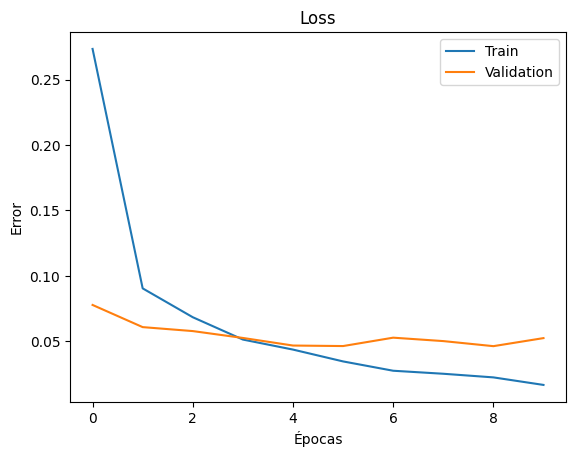

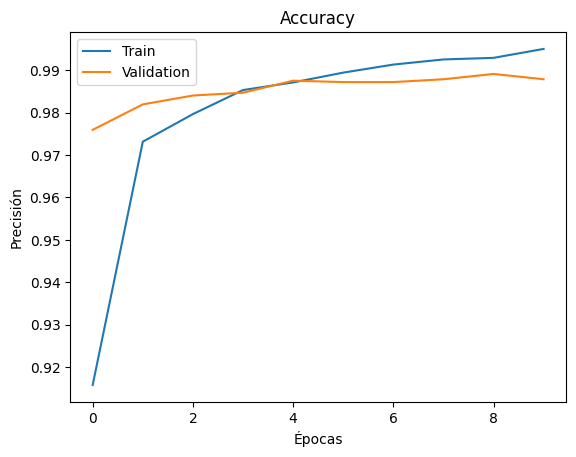

Sube un número dibujado a mano:


Saving 4.4.jpeg to 4.4 (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


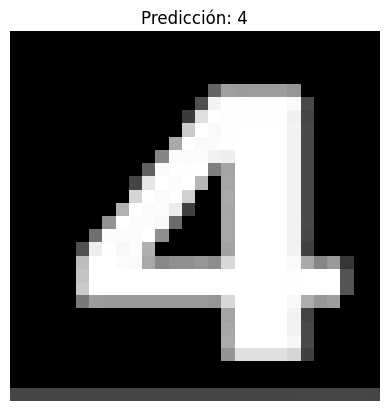

El modelo predice: 4
Generando matriz de confusión...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


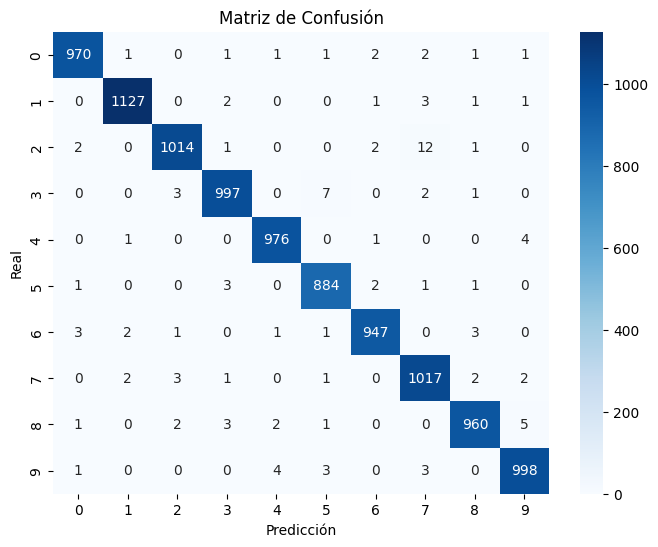

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix
from PIL import Image as PILImage
from google.colab import files
import io

MODEL_PATH = "modelo_mnist_cnn.h5"


(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
def create_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Entrenando modelo...")

model = create_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(['Train', 'Validation'])
plt.show()

print("Sube un número dibujado a mano:")
uploaded = files.upload()

def preprocess_image(image_file):
    img = PILImage.open(image_file).convert('L')
    img = img.resize((28, 28))

    img_array = np.array(img) / 255.0

    if img_array.mean() > 0.5:
        img_array = 1 - img_array

    img_array[img_array < 0.2] = 0

    img_array = img_array.reshape(1, 28, 28, 1)

    return img_array, img_array[0].reshape(28,28)

for fn in uploaded.keys():

    img_data, img_display = preprocess_image(io.BytesIO(uploaded[fn]))

    prediction = model.predict(img_data)
    pred = np.argmax(prediction)

    plt.imshow(img_display, cmap='gray')
    plt.title(f"Predicción: {pred}")
    plt.axis('off')
    plt.show()

    print("El modelo predice:", pred)

print("Generando matriz de confusión...")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()